In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/gokulrajkmv/unemployment-in-india/Unemployment_Rate_upto_11_2020.csv
/kaggle/input/datasets/gokulrajkmv/unemployment-in-india/Unemployment in India.csv


<div style="
    background: linear-gradient(135deg, #FF6B35, #F7C59F);
    padding: 30px;
    border-radius: 20px;
    text-align: center;
    color: white;
    box-shadow: 0 8px 20px rgba(0,0,0,0.15);
    margin: 20px 0;
">
    <h1 style="
        font-size: 38px;
        margin: 0;
        font-weight: bold;
    ">
        🇮🇳 Unemployment Analysis in India
    </h1>
    
   
</div>

<div style="
    background: linear-gradient(135deg, #667eea, #764ba2);
    padding: 25px;
    border-radius: 18px;
    color: white;
    margin: 20px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.15);
">
    <h2 style="
        margin: 0;
        font-size: 28px;
    ">
        🎯 Project Objective
    </h2>
    
   
</div>

## 🎯 Project Goals

This project aims to:

- Explore unemployment trends across Indian states.
- Analyze monthly unemployment patterns.
- Compare average unemployment rates across states.
- Identify the states with the highest unemployment rates.
- Analyze the relationship between unemployment, employment,
  and labour participation.
- Study the impact of COVID-19 on unemployment.
- Compare pre-COVID and post-COVID unemployment rates.
- Generate meaningful insights using data visualization.

<div style="
    background: linear-gradient(135deg, #11998e, #38ef7d);
    padding: 20px 25px;
    border-radius: 16px;
    color: white;
    margin: 20px 0;
">
    <h2 style="margin: 0;">
        📚 Import Required Libraries
    </h2>
     <h3 style="font-weight: normal;">
        Loading Python libraries required for data analysis and visualization.
    </h3>
</div>

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
%matplotlib inline

# Seaborn style
sns.set_style("whitegrid")

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


<div style="
    background: linear-gradient(135deg, #2193b0, #6dd5ed);
    padding: 22px 26px;
    border-radius: 17px;
    color: white;
    margin: 20px 0;
">
    <h2 style="margin: 0;">
        📥 Load Unemployment Dataset
    </h2>
     <h3 style="font-weight: normal;">
        Reading the unemployment dataset downloaded from Kaggle.
    </h3>
</div>

In [12]:
# Load the dataset
df = pd.read_csv("/kaggle/input/datasets/gokulrajkmv/unemployment-in-india/Unemployment_Rate_upto_11_2020.csv")


# Display first 5 rows
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


<div style="
    background: linear-gradient(135deg, #f093fb, #f5576c);
    padding: 22px 26px;
    border-radius: 17px;
    color: white;
    margin: 20px 0;
">
    <h2 style="margin: 0;">
        👀 Initial Dataset Inspection
    </h2>
</div>

In [13]:
# Display last 5 records
df.tail()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
262,West Bengal,30-06-2020,M,7.29,30726310,40.39,East,22.9868,87.855
263,West Bengal,31-07-2020,M,6.83,35372506,46.17,East,22.9868,87.855
264,West Bengal,31-08-2020,M,14.87,33298644,47.48,East,22.9868,87.855
265,West Bengal,30-09-2020,M,9.35,35707239,47.73,East,22.9868,87.855
266,West Bengal,31-10-2020,M,9.98,33962549,45.63,East,22.9868,87.855


In [14]:
# Display last 5 records
df.tail()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
262,West Bengal,30-06-2020,M,7.29,30726310,40.39,East,22.9868,87.855
263,West Bengal,31-07-2020,M,6.83,35372506,46.17,East,22.9868,87.855
264,West Bengal,31-08-2020,M,14.87,33298644,47.48,East,22.9868,87.855
265,West Bengal,30-09-2020,M,9.35,35707239,47.73,East,22.9868,87.855
266,West Bengal,31-10-2020,M,9.98,33962549,45.63,East,22.9868,87.855


<div style="
    background: linear-gradient(135deg, #4facfe, #00f2fe);
    padding: 20px 25px;
    border-radius: 16px;
    color: white;
    margin: 20px 0;
">
    <h2 style="margin: 0;">
        📐 Dataset Shape
    </h2>
</div>

In [15]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\nDataset Shape:", df.shape)

Number of Rows: 267
Number of Columns: 9

Dataset Shape: (267, 9)


<div style="
    background: linear-gradient(135deg, #a8edea, #fed6e3);
    padding: 20px 25px;
    border-radius: 16px;
    margin: 20px 0;
">
    <h2 style="color: #374151; margin: 0;">
        🔤 Data Types
    </h2>
      <h3 style="
        color: #4b5563;
        font-weight: normal;
    ">
        Checking the data type of every column.
    </h3>
</div>

In [16]:
df.dtypes

Region                                       object
 Date                                        object
 Frequency                                   object
 Estimated Unemployment Rate (%)            float64
 Estimated Employed                           int64
 Estimated Labour Participation Rate (%)    float64
Region.1                                     object
longitude                                   float64
latitude                                    float64
dtype: object

<div style="
    background: linear-gradient(135deg, #ff9a9e, #fad0c4);
    padding: 20px 25px;
    border-radius: 16px;
    margin: 20px 0;
">
    <h2 style="color: #7b1e3a; margin: 0;">
        🔍 Missing Value Analysis
    </h2>
</div>

In [17]:
# Check missing values
missing_values = df.isnull().sum()

print(missing_values)

print(
    "\nTotal Missing Values:",
    df.isnull().sum().sum()
)

Region                                      0
 Date                                       0
 Frequency                                  0
 Estimated Unemployment Rate (%)            0
 Estimated Employed                         0
 Estimated Labour Participation Rate (%)    0
Region.1                                    0
longitude                                   0
latitude                                    0
dtype: int64

Total Missing Values: 0


### 📝 Observation

The missing-value analysis identifies whether any columns contain
incomplete observations.

If missing values are present, they should be handled before performing
statistical analysis or visualization.

<div style="
    background: linear-gradient(135deg, #84fab0, #8fd3f4);
    padding: 20px 25px;
    border-radius: 16px;
    margin: 20px 0;
">
    <h2 style="color: #075985; margin: 0;">
        🧹 Data Cleaning
    </h2>
</div>

In [18]:
# Remove leading/trailing spaces from column names
df.columns = df.columns.str.strip()

# Display cleaned column names
print(df.columns.tolist())

['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Region.1', 'longitude', 'latitude']


<div style="
    background: linear-gradient(135deg, #667eea, #764ba2);
    padding: 20px 25px;
    border-radius: 16px;
    color: white;
    margin: 20px 0;
">
    <h2 style="margin: 0;">
        📅 Date Conversion
    </h2>
    <h3 style="font-weight: normal;">
        Converting the Date column into Pandas datetime format
        for time-series analysis.
    </h3>
</div>

In [19]:
# Convert Date to datetime
df["Date"] = pd.to_datetime(
    df["Date"],
    dayfirst=True,
    errors="coerce"
)

# Check result
df[["Date"]].head()

,Date
0,2020-01-31
1,2020-02-29
2,2020-03-31
3,2020-04-30
4,2020-05-31


<div style="
    background: linear-gradient(135deg, #f6d365, #fda085);
    padding: 20px 25px;
    border-radius: 16px;
    margin: 20px 0;
">
    <h2 style="color: #5c3317; margin: 0;">
        📋 Dataset Information
    </h2>
</div>

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   267 non-null    object        
 1   Date                                     267 non-null    datetime64[ns]
 2   Frequency                                267 non-null    object        
 3   Estimated Unemployment Rate (%)          267 non-null    float64       
 4   Estimated Employed                       267 non-null    int64         
 5   Estimated Labour Participation Rate (%)  267 non-null    float64       
 6   Region.1                                 267 non-null    object        
 7   longitude                                267 non-null    float64       
 8   latitude                                 267 non-null    float64       
dtypes: datetime64[ns](1), float64(4), int64(1), 

<div style="
    background: linear-gradient(135deg, #c471f5, #fa71cd);
    padding: 20px 25px;
    border-radius: 16px;
    color: white;
    margin: 20px 0;
">
    <h2 style="margin: 0;">
        📊 Descriptive Statistics
    </h2>
</div>

In [21]:
df.describe()

,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),longitude,latitude
count,267,267.000000,2.670000e+02,267.000000,267.000000,267.000000
mean,2020-06-16 09:15:30.337078528,12.236929,1.396211e+07,41.681573,22.826048,80.532425
min,2020-01-31 00:00:00,0.500000,1.175420e+05,16.770000,10.850500,71.192400
25%,2020-03-31 00:00:00,4.845000,2.838930e+06,37.265000,18.112400,76.085600
50%,2020-06-30 00:00:00,9.650000,9.732417e+06,40.390000,23.610200,79.019300
75%,2020-08-31 00:00:00,16.755000,2.187869e+07,44.055000,27.278400,85.279900
max,2020-10-31 00:00:00,75.850000,5.943376e+07,69.690000,33.778200,92.937600
std,NaN,10.803283,1.336632e+07,7.845419,6.270731,5.831738


<div style="
    background: linear-gradient(135deg, #ff758c, #ff7eb3);
    padding: 22px 26px;
    border-radius: 17px;
    color: white;
    margin: 20px 0;
">
    <h2 style="margin: 0;">
        🗺️ States & Regions in Dataset
    </h2>
</div>

In [22]:
# Display unique states/regions

states = df["Region"].unique()

print("Number of States/Regions:", len(states))
print("\nStates/Regions:")
print(states)

Number of States/Regions: 27

States/Regions:
['Andhra Pradesh' 'Assam' 'Bihar' 'Chhattisgarh' 'Delhi' 'Goa' 'Gujarat'
 'Haryana' 'Himachal Pradesh' 'Jammu & Kashmir' 'Jharkhand' 'Karnataka'
 'Kerala' 'Madhya Pradesh' 'Maharashtra' 'Meghalaya' 'Odisha' 'Puducherry'
 'Punjab' 'Rajasthan' 'Sikkim' 'Tamil Nadu' 'Telangana' 'Tripura'
 'Uttar Pradesh' 'Uttarakhand' 'West Bengal']


<div style="
    background: linear-gradient(135deg, #ff9966, #ff5e62);
    padding: 22px 26px;
    border-radius: 17px;
    color: white;
    margin: 20px 0;
">
    <h2 style="margin: 0;">
        📊 Region-wise Average Unemployment
    </h2>
    <h3 style="font-weight: normal;">
        Calculating the average unemployment rate for every Indian state.
    </h3>
</div>

In [23]:
# Average unemployment rate by state

state_avg = (
    df.groupby("Region")[
        "Estimated Unemployment Rate (%)"
    ]
    .mean()
    .sort_values(ascending=False)
)

state_avg

Region
Haryana             27.477000
Tripura             25.055000
Jharkhand           19.539000
Bihar               19.471000
Delhi               18.414000
Puducherry          17.942000
Jammu & Kashmir     16.477778
Himachal Pradesh    16.065000
Rajasthan           15.868000
Tamil Nadu          12.187000
Goa                 12.167000
Punjab              11.981000
Uttarakhand         11.156000
West Bengal         10.192000
Sikkim               9.792500
Uttar Pradesh        9.737000
Kerala               9.434000
Andhra Pradesh       8.664000
Maharashtra          7.979000
Chhattisgarh         7.819000
Karnataka            7.668000
Madhya Pradesh       6.854000
Telangana            6.833000
Odisha               6.462000
Gujarat              6.376000
Assam                4.856000
Meghalaya            3.866000
Name: Estimated Unemployment Rate (%), dtype: float64

### 📝 Observation

The average unemployment rate varies significantly across Indian states.

Some states show substantially higher unemployment than others,
indicating strong regional differences in labour-market conditions.

<div style="
    background: linear-gradient(135deg, #f7971e, #ffd200);
    padding: 22px 26px;
    border-radius: 17px;
    margin: 20px 0;
">
    <h2 style="color: #713f12; margin: 0;">
        🏆 Top 10 States with Highest Unemployment
    </h2>
</div>

In [25]:
# Select top 10 states

top_10_states = state_avg.head(10)

print("Top 10 States:")
display(top_10_states)

Top 10 States:


Region
Haryana             27.477000
Tripura             25.055000
Jharkhand           19.539000
Bihar               19.471000
Delhi               18.414000
Puducherry          17.942000
Jammu & Kashmir     16.477778
Himachal Pradesh    16.065000
Rajasthan           15.868000
Tamil Nadu          12.187000
Name: Estimated Unemployment Rate (%), dtype: float64

<div style="
    background: linear-gradient(135deg, #ee0979, #ff6a00);
    padding: 22px 26px;
    border-radius: 17px;
    color: white;
    margin: 20px 0;
">
    <h2 style="margin: 0;">
        📊 Top 10 States by Average Unemployment
    </h2>
</div>

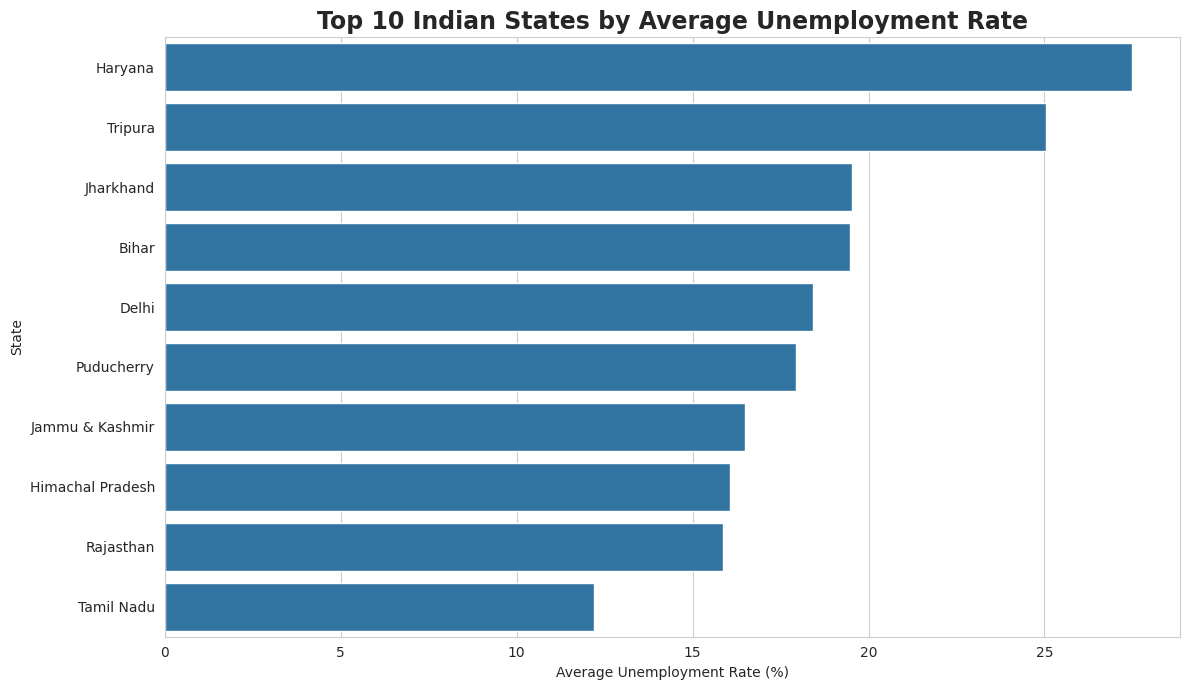

In [26]:
plt.figure(figsize=(12, 7))

sns.barplot(
    x=top_10_states.values,
    y=top_10_states.index
)

plt.title(
    "Top 10 Indian States by Average Unemployment Rate",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("State")

plt.tight_layout()
plt.show()

### 📝 Observation

The bar chart highlights the ten states with the highest average
unemployment rates in the dataset.

This comparison makes it easier to identify regions that experienced
relatively higher unemployment during the period covered by the dataset.

<div style="
    background: linear-gradient(135deg, #00c6ff, #0072ff);
    padding: 22px 26px;
    border-radius: 17px;
    color: white;
    margin: 20px 0;
">
    <h2 style="margin: 0;">
        📈 Monthly Unemployment Trend in India
    </h2>
</div>

In [27]:
# Calculate India's average unemployment rate for each month

monthly_unemployment = (
    df.groupby("Date")[
        "Estimated Unemployment Rate (%)"
    ]
    .mean()
    .reset_index()
)

monthly_unemployment.head()

,Date,Estimated Unemployment Rate (%)
0,2020-01-31,9.196538
1,2020-02-29,9.266154
2,2020-03-31,10.782593
3,2020-04-30,22.236154
4,2020-05-31,23.244444


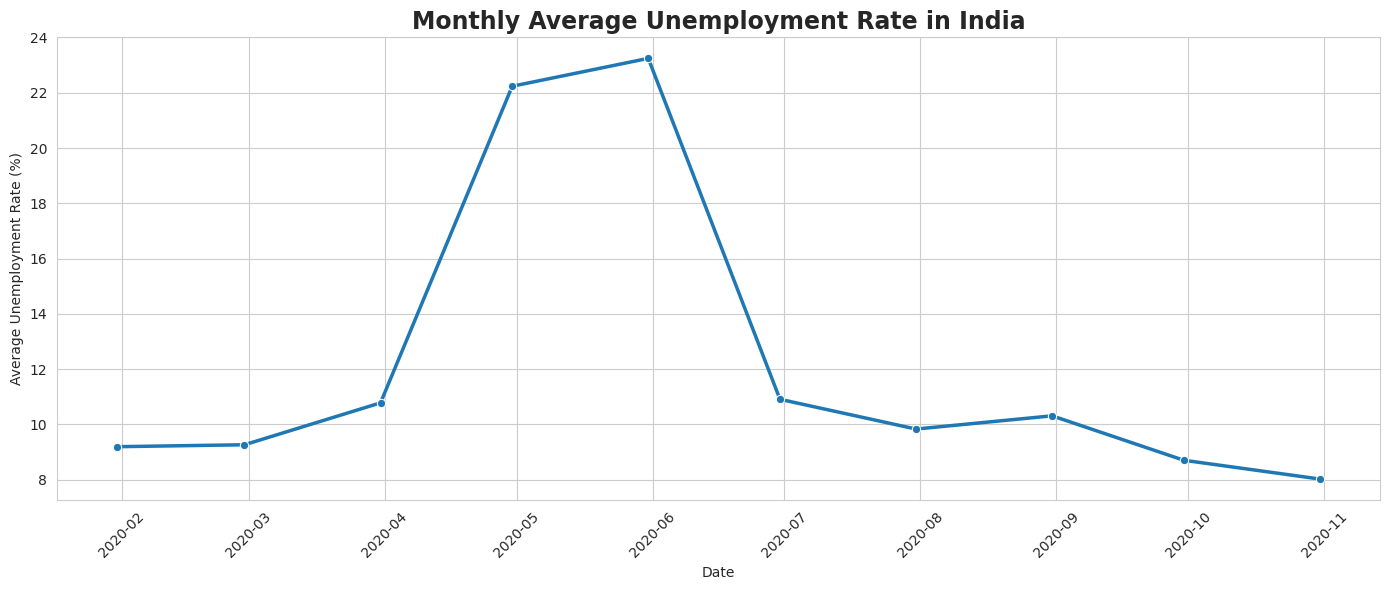

In [28]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=monthly_unemployment,
    x="Date",
    y="Estimated Unemployment Rate (%)",
    marker="o",
    linewidth=2.5
)

plt.title(
    "Monthly Average Unemployment Rate in India",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Date")
plt.ylabel("Average Unemployment Rate (%)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### 📝 Observation

The bar chart highlights the ten states with the highest average
unemployment rates in the dataset.

This comparison makes it easier to identify regions that experienced
relatively higher unemployment during the period covered by the dataset.

<div style="
    background: linear-gradient(135deg, #00c6ff, #0072ff);
    padding: 22px 26px;
    border-radius: 17px;
    color: white;
    margin: 20px 0;
">
    <h2 style="margin: 0;">
        📈 Monthly Unemployment Trend in India
    </h2>
</div>

In [29]:
# Calculate India's average unemployment rate for each month

monthly_unemployment = (
    df.groupby("Date")[
        "Estimated Unemployment Rate (%)"
    ]
    .mean()
    .reset_index()
)

monthly_unemployment.head()

,Date,Estimated Unemployment Rate (%)
0,2020-01-31,9.196538
1,2020-02-29,9.266154
2,2020-03-31,10.782593
3,2020-04-30,22.236154
4,2020-05-31,23.244444


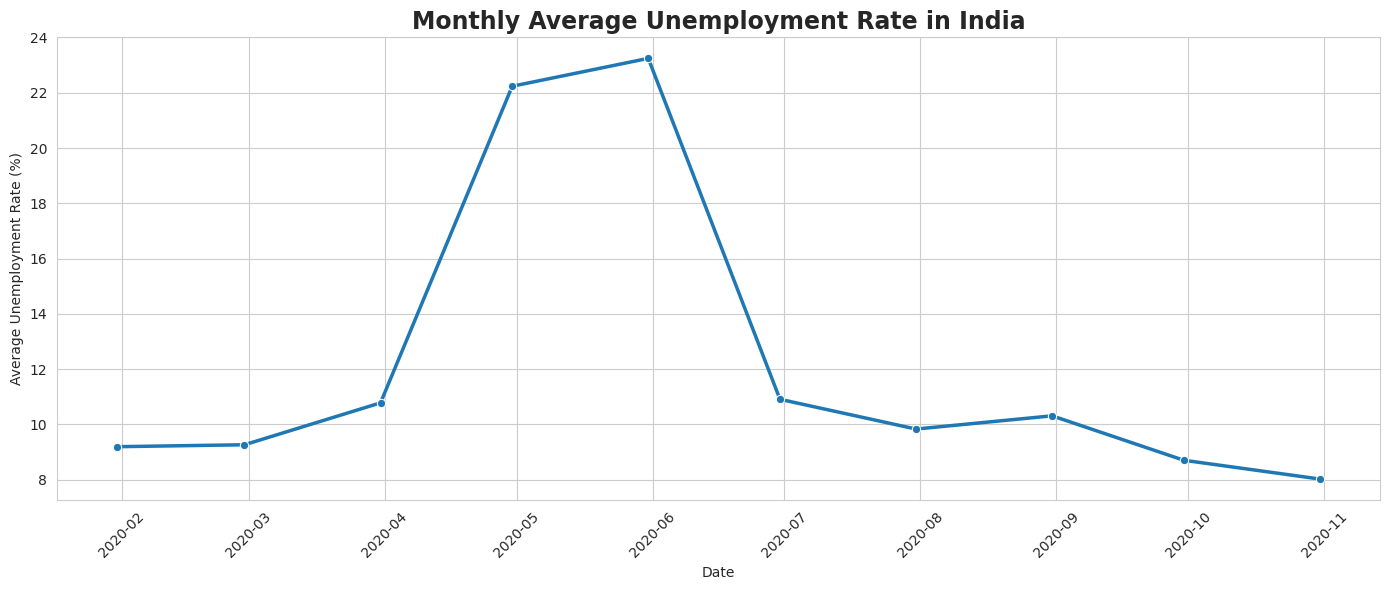

In [30]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=monthly_unemployment,
    x="Date",
    y="Estimated Unemployment Rate (%)",
    marker="o",
    linewidth=2.5
)

plt.title(
    "Monthly Average Unemployment Rate in India",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Date")
plt.ylabel("Average Unemployment Rate (%)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### 📝 Observation

The monthly trend shows noticeable fluctuations in India's unemployment
rate over time.

A particularly important period is the early COVID-19 period, when
unemployment increased sharply in several states.

<div style="
    background: linear-gradient(135deg, #8E2DE2, #4A00E0);
    padding: 22px 26px;
    border-radius: 17px;
    color: white;
    margin: 20px 0;
">
    <h2 style="margin: 0;">
        🦠 State-wise COVID-19 Trend Analysis
    </h2>
     <h3 style="font-weight: normal;">
        Comparing unemployment trends across selected Indian states.
    </h3>
</div>

In [31]:
# Select states for time-series analysis

selected_states = [
    "Haryana",
    "Rajasthan",
    "Bihar",
    "Tamil Nadu"
]

state_trend = df[
    df["Region"].isin(selected_states)
]

state_trend["Region"].unique()


array(['Bihar', 'Haryana', 'Rajasthan', 'Tamil Nadu'], dtype=object)

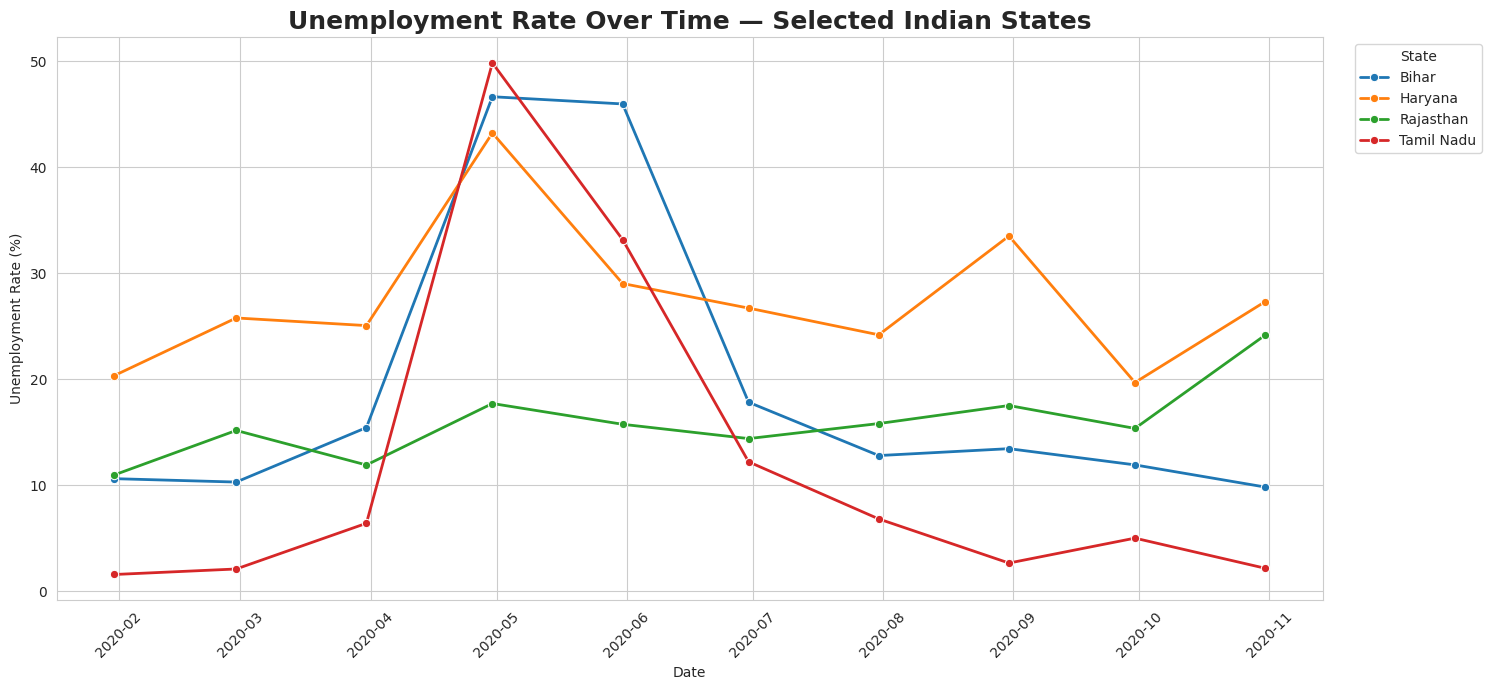

In [32]:
plt.figure(figsize=(15, 7))

sns.lineplot(
    data=state_trend,
    x="Date",
    y="Estimated Unemployment Rate (%)",
    hue="Region",
    marker="o",
    linewidth=2
)

plt.title(
    "Unemployment Rate Over Time — Selected Indian States",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")

plt.xticks(rotation=45)

plt.legend(
    title="State",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

### 📝 Observation

The selected states show different unemployment patterns over time.

The sharp changes around early 2020 correspond to the period when
COVID-19 and nationwide lockdown measures disrupted economic activity.

The magnitude and duration of the unemployment increase differ
between states.

<div style="
    background: linear-gradient(135deg, #11998e, #38ef7d);
    padding: 22px 26px;
    border-radius: 17px;
    color: white;
    margin: 20px 0;
">
    <h2 style="margin: 0;">
        📦 State-wise Unemployment Distribution
    </h2>
</div>

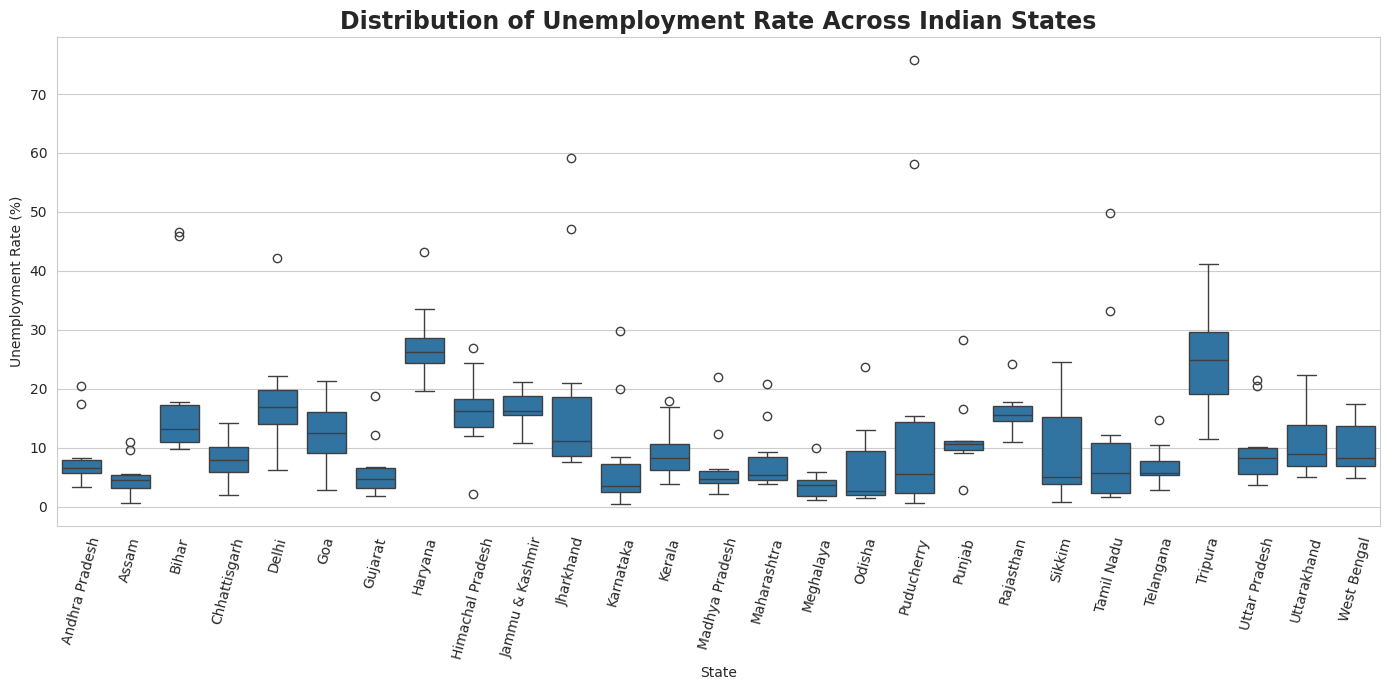

In [33]:
plt.figure(figsize=(14, 7))

sns.boxplot(
    data=df,
    x="Region",
    y="Estimated Unemployment Rate (%)"
)

plt.title(
    "Distribution of Unemployment Rate Across Indian States",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("State")
plt.ylabel("Unemployment Rate (%)")

plt.xticks(rotation=75)

plt.tight_layout()
plt.show()

### 📝 Observation

The box plot shows the distribution, spread, and potential outliers
of unemployment rates across states.

States with wider boxes experienced greater variation in unemployment
during the observed period.

<div style="
    background: linear-gradient(135deg, #ff416c, #ff4b2b);
    padding: 22px 26px;
    border-radius: 17px;
    color: white;
    margin: 20px 0;
">
    <h2 style="margin: 0;">
        🔥 Correlation Matrix
    </h2>
    <h3 style="font-weight: normal;">
        Measuring relationships between key labour-market indicators.
    </h3>
</div>

In [34]:
# Select numerical labour-market variables

correlation_columns = [
    "Estimated Unemployment Rate (%)",
    "Estimated Employed",
    "Estimated Labour Participation Rate (%)"
]

correlation_matrix = df[
    correlation_columns
].corr()

correlation_matrix

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
Estimated Unemployment Rate (%),1.000000,-0.245176,-0.073540
Estimated Employed,-0.245176,1.000000,-0.047948
Estimated Labour Participation Rate (%),-0.073540,-0.047948,1.000000


<div style="
    background: linear-gradient(135deg, #FC466B, #3F5EFB);
    padding: 22px 26px;
    border-radius: 17px;
    color: white;
    margin: 20px 0;
">
    <h2 style="margin: 0;">
        🔥 Labour Market Correlation Heatmap
    </h2>
</div>

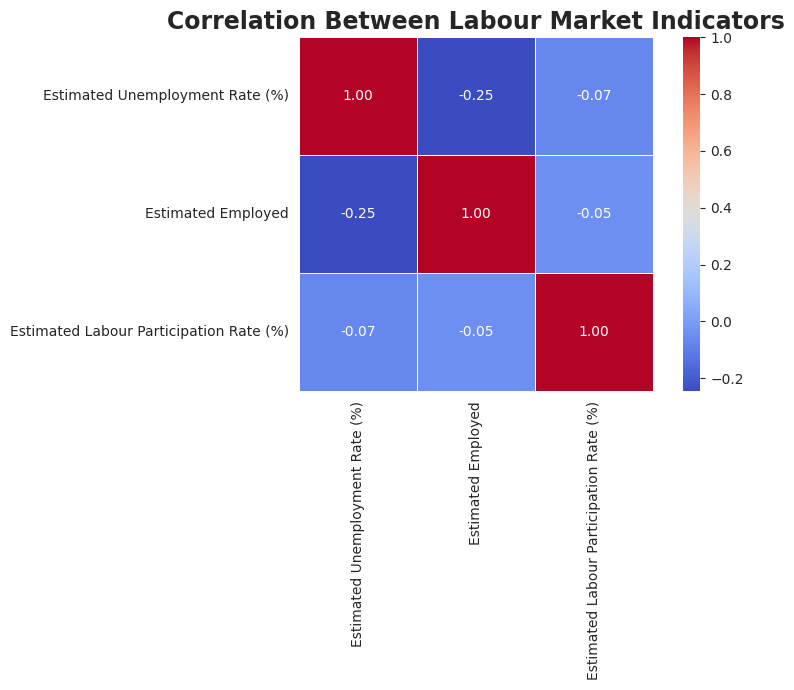

In [35]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True
)

plt.title(
    "Correlation Between Labour Market Indicators",
    fontsize=17,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

### 📝 Observation

The correlation heatmap shows how the major labour-market variables
move in relation to one another.

A positive correlation indicates that two variables tend to increase
together, while a negative correlation indicates an inverse relationship.

> Correlation describes association and does not establish causation.

<div style="
    background: linear-gradient(135deg, #667eea, #764ba2);
    padding: 25px;
    border-radius: 18px;
    color: white;
    margin: 20px 0;
">
    <h2 style="margin: 0;">
        🦠 COVID-19 Period Analysis
    </h2>
     <h3 style="font-weight: normal;">
        Comparing unemployment before and during the COVID-19 period.
    </h3>
</div>

In [36]:
# Define COVID-19 comparison date

covid_date = pd.Timestamp("2020-03-01")

# Create period classification
df["COVID_Period"] = np.where(
    df["Date"] < covid_date,
    "Pre-COVID",
    "COVID Period"
)

# Check distribution
df["COVID_Period"].value_counts()

COVID_Period
COVID Period    215
Pre-COVID        52
Name: count, dtype: int64

<div style="
    background: linear-gradient(135deg, #f7971e, #ffd200);
    padding: 22px 26px;
    border-radius: 17px;
    margin: 20px 0;
">
    <h2 style="color: #713f12; margin: 0;">
        📊 Pre-COVID vs COVID Comparison
    </h2>
</div>

In [37]:
period_average = (
    df.groupby("COVID_Period")[
        [
            "Estimated Unemployment Rate (%)",
            "Estimated Employed",
            "Estimated Labour Participation Rate (%)"
        ]
    ]
    .mean()
)

period_average

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
COVID_Period,,,
COVID Period,12.963860,1.357498e+07,41.023209
Pre-COVID,9.231346,1.556273e+07,44.403654


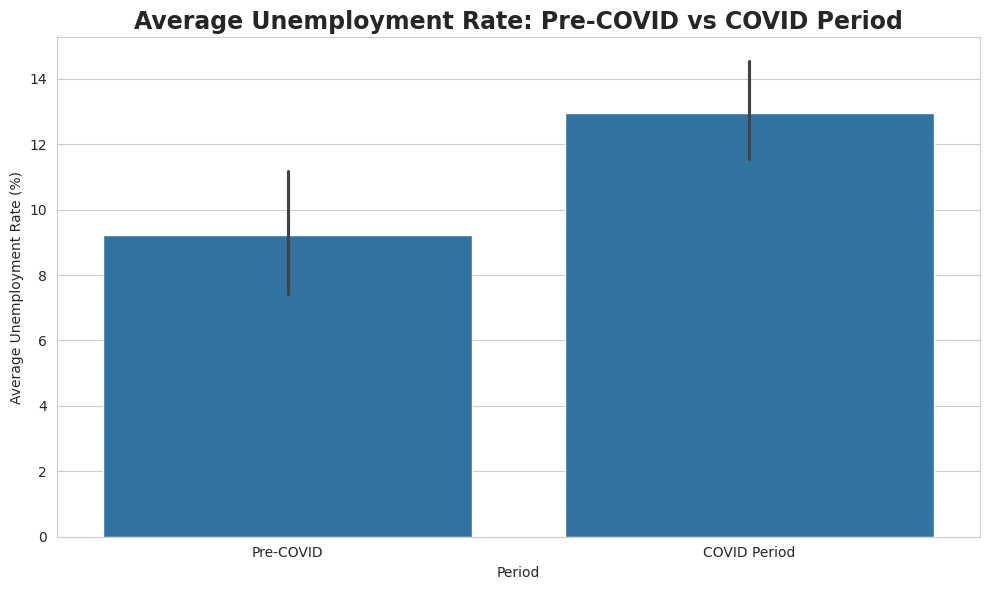

In [38]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df,
    x="COVID_Period",
    y="Estimated Unemployment Rate (%)"
)

plt.title(
    "Average Unemployment Rate: Pre-COVID vs COVID Period",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Period")
plt.ylabel("Average Unemployment Rate (%)")

plt.tight_layout()
plt.show()

### 📝 Observation

The comparison shows a noticeable difference in average unemployment
between the pre-COVID and COVID periods.

The COVID period experienced a substantial increase in unemployment
in many parts of India, reflecting the disruption caused by lockdowns,
business closures, and reduced economic activity.

The exact magnitude depends on the states and months included in
the dataset.

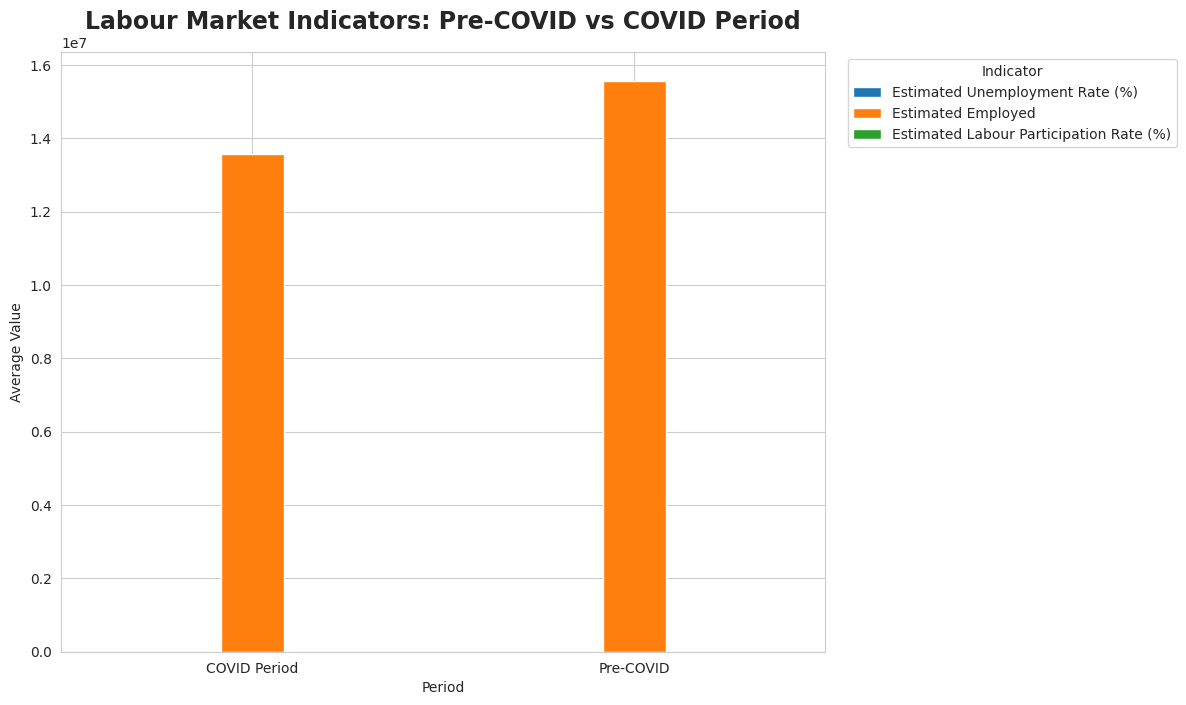

In [39]:
# Compare all three indicators between periods

period_average.plot(
    kind="bar",
    figsize=(12, 7)
)

plt.title(
    "Labour Market Indicators: Pre-COVID vs COVID Period",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Period")
plt.ylabel("Average Value")

plt.xticks(rotation=0)

plt.legend(
    title="Indicator",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

### 📝 Observation

The COVID period affected multiple labour-market indicators rather
than unemployment alone.

Changes in employment and labour-force participation provide additional
context for understanding the rise in unemployment during the pandemic.

<div style="
    background: linear-gradient(135deg, #00c6ff, #0072ff);
    padding: 22px 26px;
    border-radius: 17px;
    color: white;
    margin: 20px 0;
">
    <h2 style="margin: 0;">
        🗓️ Monthly COVID-19 Unemployment Trend
    </h2>
</div>

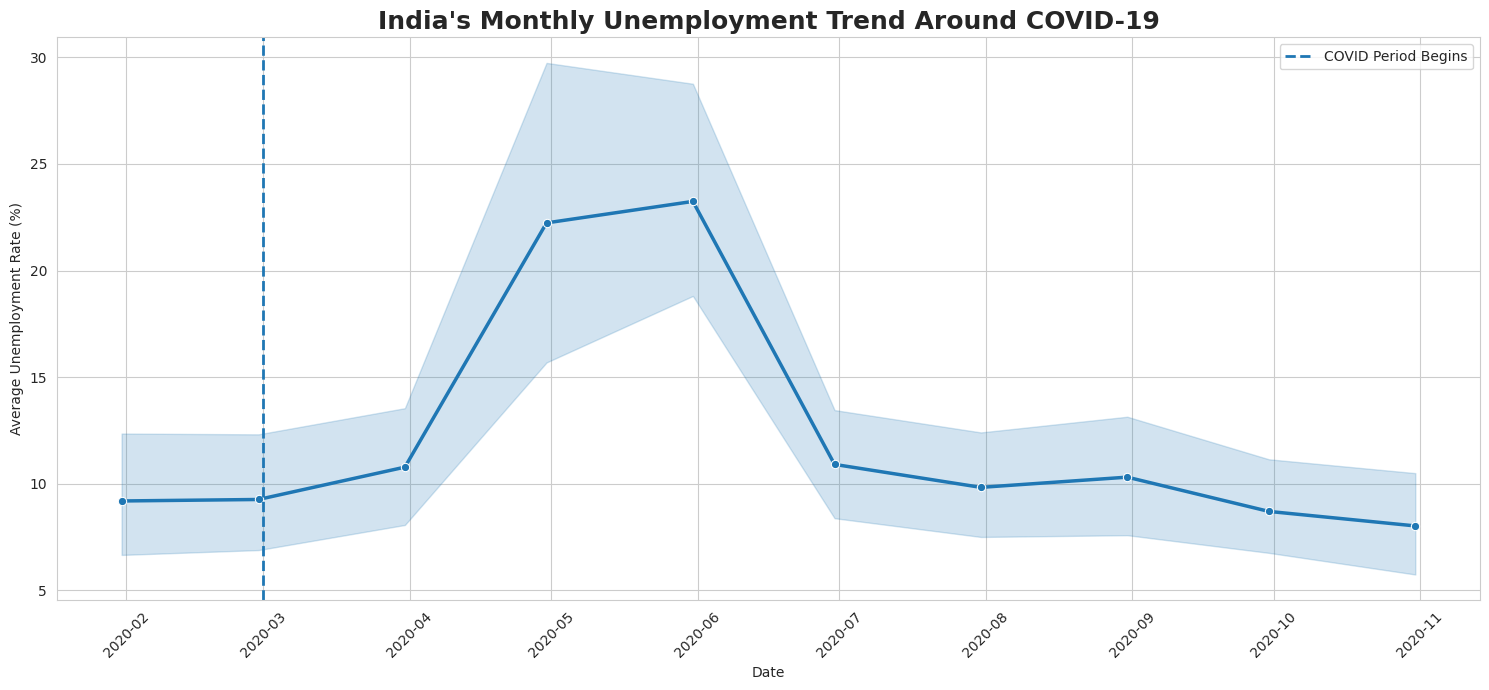

In [40]:
plt.figure(figsize=(15, 7))

sns.lineplot(
    data=df,
    x="Date",
    y="Estimated Unemployment Rate (%)",
    marker="o",
    linewidth=2.5
)

# Mark COVID starting point
plt.axvline(
    covid_date,
    linestyle="--",
    linewidth=2,
    label="COVID Period Begins"
)

plt.title(
    "India's Monthly Unemployment Trend Around COVID-19",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Date")
plt.ylabel("Average Unemployment Rate (%)")

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### 📝 Observation

The vertical line marks the beginning of the COVID comparison period.

The unemployment rate shows a sharp change around the beginning of
the pandemic, illustrating the labour-market disruption associated
with the COVID-19 period.

<div style="
    background: linear-gradient(135deg, #ff416c, #ff4b2b);
    padding: 22px 26px;
    border-radius: 17px;
    color: white;
    margin: 20px 0;
">
    <h2 style="margin: 0;">
        🚨 Highest Unemployment Month
    </h2>
</div>

In [41]:
highest_month = monthly_unemployment.loc[
    monthly_unemployment[
        "Estimated Unemployment Rate (%)"
    ].idxmax()
]

print(
    "Highest Average Unemployment Month:"
)

print(
    highest_month["Date"].strftime("%B %Y")
)

print(
    "Average Unemployment Rate:",
    round(
        highest_month[
            "Estimated Unemployment Rate (%)"
        ],
        2
    ),
    "%"
)

Highest Average Unemployment Month:
May 2020
Average Unemployment Rate: 23.24 %


### 📝 Observation

The highest monthly unemployment value provides a useful indicator
of the period when unemployment reached its maximum level in the
dataset.

This peak can be compared with the timing of COVID-19 lockdowns
and economic restrictions.

<div style="
    background: linear-gradient(135deg, #f6d365, #fda085);
    padding: 22px 26px;
    border-radius: 17px;
    margin: 20px 0;
">
    <h2 style="color: #5c3317; margin: 0;">
         Highest Average Unemployment State
    </h2>
</div>

In [42]:
highest_state = state_avg.idxmax()
highest_state_rate = state_avg.max()

print("State:", highest_state)
print(
    "Average Unemployment Rate:",
    round(highest_state_rate, 2),
    "%"
)

State: Haryana
Average Unemployment Rate: 27.48 %


<div style="
    background: linear-gradient(135deg, #11998e, #38ef7d);
    padding: 28px;
    border-radius: 20px;
    margin: 25px 0;
    box-shadow: 0 8px 22px rgba(0,0,0,0.15);
">
    <h1 style="
        color: #064e3b;
        text-align: center;
        margin: 0;
    ">
        🔑 Key Findings
    </h1>
</div>

## 🔑 Key Findings

### 1. 📍 Regional Variation
Unemployment rates differ considerably across Indian states.

### 2. 📅 Monthly Variation
The unemployment rate changes substantially from month to month,
showing clear temporal variation.

### 3. 🦠 COVID-19 Impact
The COVID-19 period is associated with a major disruption in
India's labour market.

### 4. 📈 Unemployment Spike
The dataset shows a significant increase in unemployment around
the early COVID-19 period.

### 5. 🏆 State Differences
Some states consistently show higher average unemployment than others.

### 6. 👥 Labour Participation
Changes in labour-force participation provide additional context
when interpreting unemployment.

### 7. 💼 Employment
The estimated employment figures also changed considerably during
the COVID period.

### 8. 🔥 Correlation
The correlation analysis helps identify relationships between
unemployment, employment, and labour-force participation.

<div style="
    background: linear-gradient(135deg, #667eea, #764ba2);
    padding: 30px;
    border-radius: 22px;
    text-align: center;
    color: white;
    margin: 25px 0;
    box-shadow: 0 8px 24px rgba(0,0,0,0.2);
">
    <h1 style="
        margin: 0;
        font-size: 32px;
    ">
        🎯 Final Conclusion
    </h1>
    <h3 style="
        font-weight: normal;
        line-height: 1.7;
    ">
        This analysis demonstrates how Python can be used to explore
        regional and temporal unemployment trends in India.
        The COVID-19 period produced substantial labour-market
        disruption, with unemployment increasing sharply during
        the pandemic period in the dataset.
    </h3>
</div>

## 🎯 Conclusion

This project provided a comprehensive exploratory analysis of
unemployment in India using Python.

The analysis examined:

- Regional unemployment differences
- Monthly unemployment trends
- State-wise unemployment averages
- Top 10 states with highest unemployment
- Labour-market correlations
- Employment trends
- Labour-force participation
- COVID-19 period changes

The findings demonstrate that unemployment in India varies significantly
across regions and over time. The COVID-19 pandemic created a major
disruption in employment conditions, which is visible through the
sharp changes in unemployment during 2020.

Overall, this project demonstrates the importance of Exploratory Data
Analysis and data visualization in understanding real-world economic
and social problems.

<div style="
    background: linear-gradient(135deg, #2c3e50, #4ca1af);
    padding: 25px;
    border-radius: 20px;
    text-align: center;
    color: white;
    margin: 25px 0;
">
    <h2 style="margin: 0;">
        📚 Dataset & References
    </h2>
    <h3 style="font-weight: normal;">
        Kaggle • Unemployment in India
    </h3>
</div>

## 📚 Dataset Source

**Dataset:** Unemployment in India

**Platform:** Kaggle

The dataset contains monthly unemployment information for Indian
states and includes:

- Region
- Date
- Frequency
- Estimated Unemployment Rate (%)
- Estimated Employed
- Estimated Labour Participation Rate (%)
- Area / Region classification

The dataset is specifically useful for studying unemployment trends
and the impact of COVID-19 on employment in India.